# LSTM

## Import libraries

In [402]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from lightning.pytorch.callbacks import EarlyStopping


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import TRAINED_MODELS_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from visualizer.visualizer import Visualizer

## Parameters

In [403]:
FROM_DATE = "2000-01-01"
TO_DATE = "2020-31-12"

In [404]:
INPUT_SIZE = 60
OUTPUT_SIZE = 20
NUMBER_OF_TRAIN_WINDOW = 2000
NUMBER_OF_VALIDATION_WINDOW = 200
NUMBER_OF_TEST_WINDOW = 200

## Hyper Parameters

In [405]:
MAX_EPOCHS = 300
LEARNING_RATE = 0.001
PATIENCE = 30

## Start

### Get data

In [406]:
my_logger = Logger(file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/lstm/test")

In [407]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [408]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [409]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [410]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = vn_index_df.astype(dtype_map)

In [411]:
vn_index_df

,date,open,high,low,close,volume
0,2000-01-03,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
9308,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9309,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9310,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9311,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [412]:
vn_index_transform_df = (
    vn_index_df.copy().dropna(subset=["close"]).reset_index(drop=True)
)

In [413]:
vn_index_transform_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
9099,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9100,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9101,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9102,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [414]:
vn_index_transform_sub_df = (
    vn_index_transform_df[
        (vn_index_transform_df["date"] >= FROM_DATE)
        & (vn_index_transform_df["date"] <= TO_DATE)
    ]
    .copy()
    .reset_index(drop=True)
)

In [415]:
vn_index_transform_sub_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
7457,2019-08-18,980.986667,985.523333,977.740000,980.686667,120713717.0
7458,2019-09-14,979.736667,989.013333,979.540000,988.100000,139949737.0
7459,2020-07-19,871.600000,873.036667,864.896667,864.940000,244504907.0
7460,2020-11-01,925.863333,931.226667,919.826667,930.943333,266836427.0


### Create plot

In [416]:
my_visualizer = Visualizer(logger=my_logger)

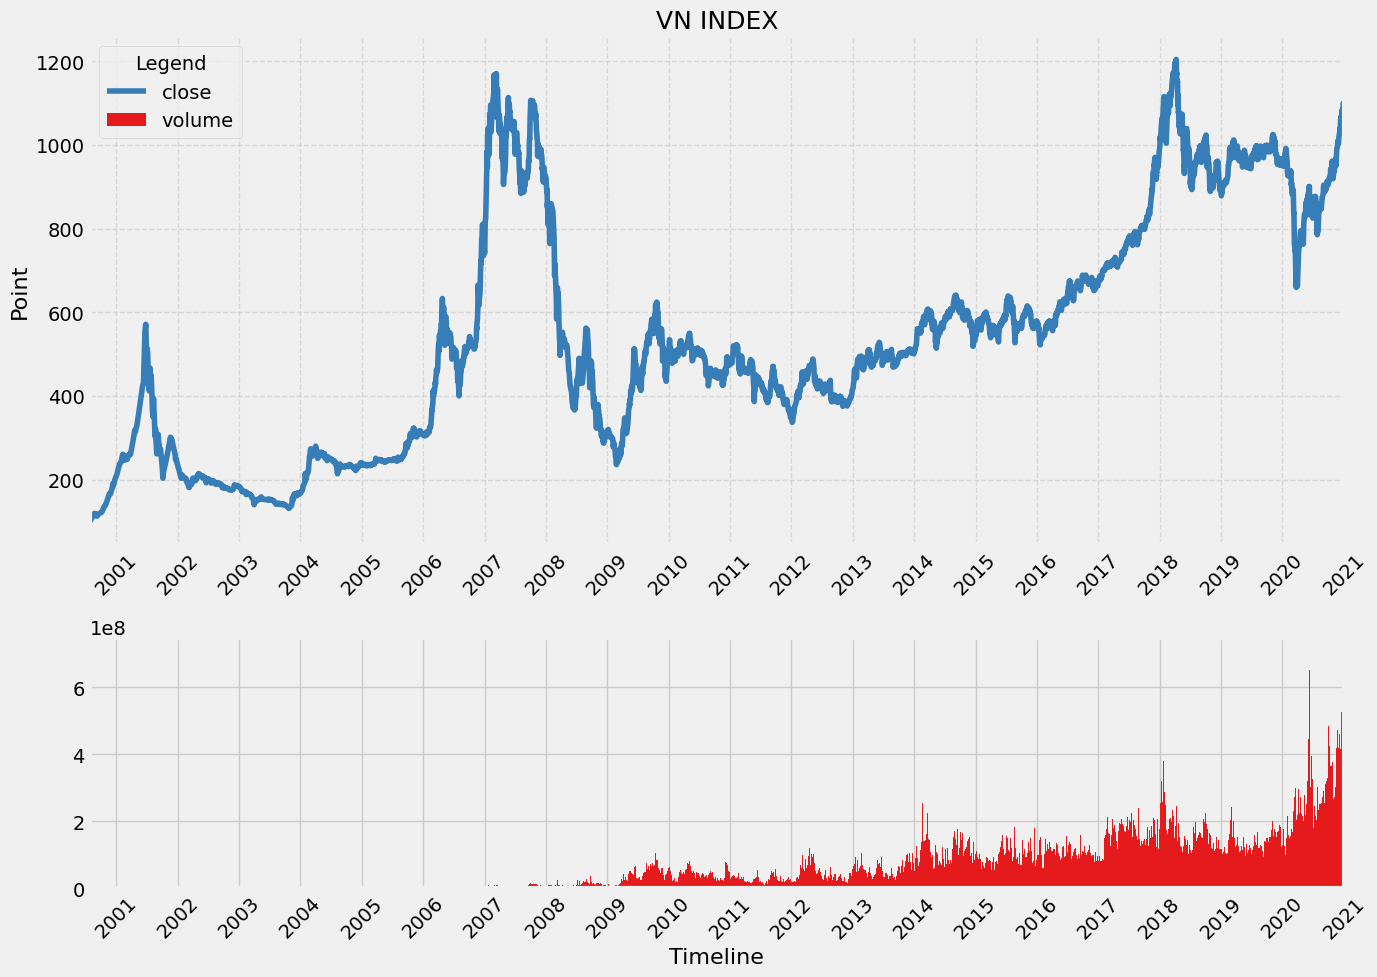

In [417]:
vn_index_plot = my_visualizer.plot_lines_bars_chart(
    vn_index_transform_sub_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="VN INDEX",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    suffix_figure_name=f"{FROM_DATE}_{TO_DATE}",
    marker=None,
    min_date_offset=pd.DateOffset(days=2),
    max_date_offset=pd.DateOffset(days=2),
)
vn_index_plot

### Create train validation test 

In [418]:
data = vn_index_transform_sub_df["close"].copy().tolist()

In [419]:
len(data)

7462

In [420]:
train_range = (0, INPUT_SIZE + NUMBER_OF_TRAIN_WINDOW + OUTPUT_SIZE)
validation_window_range = (
    train_range[1],
    train_range[1] + INPUT_SIZE + OUTPUT_SIZE + NUMBER_OF_VALIDATION_WINDOW,
)
test_range = (
    validation_window_range[1],
    validation_window_range[1] + INPUT_SIZE + OUTPUT_SIZE + NUMBER_OF_TEST_WINDOW,
)
print(train_range, validation_window_range, test_range)

(0, 2080) (2080, 2360) (2360, 2640)


In [421]:
train_set = np.array(data[train_range[0] : train_range[1]]).reshape(-1, 1)
validation_window = np.array(
    data[validation_window_range[0] : validation_window_range[1]]
).reshape(-1, 1)
test_window = np.array(data[test_range[0] : test_range[1]]).reshape(-1, 1)

In [422]:
len(train_set)

2080

In [423]:
len(validation_window)

280

In [424]:
len(test_window)

280

In [425]:
# Create scaler
scaler = MinMaxScaler()

# Fit scaler ONLY on train data
train_scaled = scaler.fit_transform(train_set)

validation_scaled = scaler.transform(validation_window)

# Transform test data using same scaler
test_scaled = scaler.transform(test_window)

print("Train scaled shape:", train_scaled.shape)
print("Validation scaled shape:", validation_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Train scaled shape: (2080, 1)
Validation scaled shape: (280, 1)
Test scaled shape: (280, 1)


In [426]:
scaler.data_min_, scaler.data_max_

(array([106.34666667]), array([632.69]))

In [427]:
train_inputs = []
train_outputs = []

for i in range(NUMBER_OF_TRAIN_WINDOW + 1):
    train_input = train_scaled[i : i + INPUT_SIZE]
    train_inputs.append(train_input.squeeze(1))
    train_output = train_scaled[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE]
    train_outputs.append(train_output.squeeze(1))

train_inputs = torch.tensor(np.array(train_inputs), dtype=torch.float32)
train_outputs = torch.tensor(np.array(train_outputs), dtype=torch.float32)

In [428]:
len(train_inputs)

2001

In [429]:
train_inputs[:3]

tensor([[0.0011, 0.0027, 0.0044, 0.0060, 0.0076, 0.0098, 0.0109, 0.0125, 0.0142,
         0.0158, 0.0174, 0.0185, 0.0196, 0.0207, 0.0223, 0.0240, 0.0239, 0.0237,
         0.0226, 0.0214, 0.0202, 0.0185, 0.0167, 0.0150, 0.0133, 0.0127, 0.0124,
         0.0120, 0.0117, 0.0116, 0.0115, 0.0126, 0.0137, 0.0147, 0.0166, 0.0185,
         0.0204, 0.0222, 0.0223, 0.0224, 0.0225, 0.0225, 0.0225, 0.0231, 0.0236,
         0.0239, 0.0240, 0.0247, 0.0254, 0.0263, 0.0273, 0.0274, 0.0276, 0.0277,
         0.0279, 0.0281, 0.0291, 0.0301, 0.0315, 0.0328],
        [0.0027, 0.0044, 0.0060, 0.0076, 0.0098, 0.0109, 0.0125, 0.0142, 0.0158,
         0.0174, 0.0185, 0.0196, 0.0207, 0.0223, 0.0240, 0.0239, 0.0237, 0.0226,
         0.0214, 0.0202, 0.0185, 0.0167, 0.0150, 0.0133, 0.0127, 0.0124, 0.0120,
         0.0117, 0.0116, 0.0115, 0.0126, 0.0137, 0.0147, 0.0166, 0.0185, 0.0204,
         0.0222, 0.0223, 0.0224, 0.0225, 0.0225, 0.0225, 0.0231, 0.0236, 0.0239,
         0.0240, 0.0247, 0.0254, 0.0263, 0.0273, 0.

In [430]:
len(train_inputs[0])

60

In [431]:
len(train_outputs)

2001

In [432]:
train_outputs[:3]

tensor([[0.0342, 0.0362, 0.0382, 0.0402, 0.0422, 0.0436, 0.0463, 0.0483, 0.0504,
         0.0524, 0.0545, 0.0555, 0.0564, 0.0574, 0.0579, 0.0584, 0.0608, 0.0631,
         0.0639, 0.0647],
        [0.0362, 0.0382, 0.0402, 0.0422, 0.0436, 0.0463, 0.0483, 0.0504, 0.0524,
         0.0545, 0.0555, 0.0564, 0.0574, 0.0579, 0.0584, 0.0608, 0.0631, 0.0639,
         0.0647, 0.0655],
        [0.0382, 0.0402, 0.0422, 0.0436, 0.0463, 0.0483, 0.0504, 0.0524, 0.0545,
         0.0555, 0.0564, 0.0574, 0.0579, 0.0584, 0.0608, 0.0631, 0.0639, 0.0647,
         0.0655, 0.0679]])

In [433]:
len(train_outputs[0])

20

In [434]:
validation_inputs = []
validation_outputs = []

for i in range(NUMBER_OF_VALIDATION_WINDOW + 1):
    validation_input = validation_scaled[i : i + INPUT_SIZE]
    validation_inputs.append(validation_input.squeeze(1))
    validation_output = validation_scaled[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE]
    validation_outputs.append(validation_output.squeeze(1))

validation_inputs = torch.tensor(np.array(validation_inputs), dtype=torch.float32)
validation_outputs = torch.tensor(np.array(validation_outputs), dtype=torch.float32)

In [435]:
len(validation_inputs)

201

In [436]:
validation_inputs[:3]

tensor([[0.7081, 0.7050, 0.8890, 0.7157, 0.7263, 0.7342, 0.7311, 0.7445, 0.7528,
         0.7694, 0.7777, 0.7814, 0.7692, 0.7727, 0.7717, 0.7708, 0.7698, 0.7495,
         0.7682, 0.7577, 0.7656, 0.7661, 0.7666, 0.7671, 0.7766, 0.7754, 0.7733,
         0.7740, 0.7757, 0.7766, 0.7860, 0.7867, 0.8006, 0.7987, 0.8018, 0.8050,
         0.8081, 0.8199, 0.8275, 0.8139, 0.8172, 0.8164, 0.8155, 0.8146, 0.7995,
         0.7948, 0.7958, 0.7972, 0.7977, 0.7979, 0.7834, 0.7832, 0.7946, 0.8019,
         0.8003, 0.7987, 0.7971, 0.7968, 0.7940, 0.7954],
        [0.7050, 0.8890, 0.7157, 0.7263, 0.7342, 0.7311, 0.7445, 0.7528, 0.7694,
         0.7777, 0.7814, 0.7692, 0.7727, 0.7717, 0.7708, 0.7698, 0.7495, 0.7682,
         0.7577, 0.7656, 0.7661, 0.7666, 0.7671, 0.7766, 0.7754, 0.7733, 0.7740,
         0.7757, 0.7766, 0.7860, 0.7867, 0.8006, 0.7987, 0.8018, 0.8050, 0.8081,
         0.8199, 0.8275, 0.8139, 0.8172, 0.8164, 0.8155, 0.8146, 0.7995, 0.7948,
         0.7958, 0.7972, 0.7977, 0.7979, 0.7834, 0.

In [437]:
len(validation_inputs[0])

60

In [438]:
len(validation_outputs)

201

In [439]:
validation_outputs

tensor([[0.7879, 0.7824, 0.7769,  ..., 0.8539, 0.8678, 0.8616],
        [0.7824, 0.7769, 0.7715,  ..., 0.8678, 0.8616, 0.8881],
        [0.7769, 0.7715, 0.7698,  ..., 0.8616, 0.8881, 0.8947],
        ...,
        [1.8738, 1.8795, 1.8853,  ..., 1.7716, 1.7791, 1.7894],
        [1.8795, 1.8853, 1.8760,  ..., 1.7791, 1.7894, 1.7867],
        [1.8853, 1.8760, 1.8458,  ..., 1.7894, 1.7867, 1.7841]])

In [440]:
len(validation_outputs[0])

20

In [441]:
test_inputs = []
test_outputs = []

for i in range(NUMBER_OF_TEST_WINDOW + 1):
    test_input = test_scaled[i : i + INPUT_SIZE]
    test_inputs.append(test_input.squeeze(1))
    test_output = test_scaled[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE]
    test_outputs.append(test_output.squeeze(1))

test_inputs = torch.tensor(np.array(test_inputs), dtype=torch.float32)
test_outputs = torch.tensor(np.array(test_outputs), dtype=torch.float32)

In [442]:
len(test_inputs)

201

In [443]:
test_inputs[:3]

tensor([[1.7814, 1.7920, 1.7839, 1.7633, 1.7619, 1.7754, 1.7822, 1.8037, 1.7605,
         1.7435, 1.7447, 1.7254, 1.7061, 1.6868, 1.6547, 1.7236, 1.7222, 1.7179,
         1.7177, 1.7175, 1.7174, 1.7416, 1.7546, 1.7314, 1.7277, 1.7151, 1.7025,
         1.6899, 1.6985, 1.6878, 1.6683, 1.6623, 1.1022, 1.6584, 1.6645, 1.6457,
         1.6145, 1.5845, 1.5656, 1.5562, 1.5230, 1.5518, 1.5291, 1.4943, 1.4886,
         1.4830, 1.4773, 1.5020, 1.5270, 1.5805, 1.5757, 1.5588, 1.5420, 1.5252,
         1.5518, 1.5370, 1.5084, 1.4849, 1.4863, 1.4876],
        [1.7920, 1.7839, 1.7633, 1.7619, 1.7754, 1.7822, 1.8037, 1.7605, 1.7435,
         1.7447, 1.7254, 1.7061, 1.6868, 1.6547, 1.7236, 1.7222, 1.7179, 1.7177,
         1.7175, 1.7174, 1.7416, 1.7546, 1.7314, 1.7277, 1.7151, 1.7025, 1.6899,
         1.6985, 1.6878, 1.6683, 1.6623, 1.1022, 1.6584, 1.6645, 1.6457, 1.6145,
         1.5845, 1.5656, 1.5562, 1.5230, 1.5518, 1.5291, 1.4943, 1.4886, 1.4830,
         1.4773, 1.5020, 1.5270, 1.5805, 1.5757, 1.

In [444]:
len(test_inputs[0])

60

In [445]:
len(test_outputs)

201

In [446]:
test_outputs[:3]

tensor([[1.4889, 1.4997, 1.4928, 1.4843, 1.5183, 1.5228, 1.5251, 1.5128, 1.5101,
         1.5153, 1.5238, 1.5340, 1.5442, 1.5544, 1.5646, 1.5564, 1.5617, 1.5727,
         1.5683, 1.5639],
        [1.4997, 1.4928, 1.4843, 1.5183, 1.5228, 1.5251, 1.5128, 1.5101, 1.5153,
         1.5238, 1.5340, 1.5442, 1.5544, 1.5646, 1.5564, 1.5617, 1.5727, 1.5683,
         1.5639, 1.5594],
        [1.4928, 1.4843, 1.5183, 1.5228, 1.5251, 1.5128, 1.5101, 1.5153, 1.5238,
         1.5340, 1.5442, 1.5544, 1.5646, 1.5564, 1.5617, 1.5727, 1.5683, 1.5639,
         1.5594, 1.5468]])

In [447]:
len(test_outputs[0])

20

In [448]:
train_dataset = TensorDataset(train_inputs, train_outputs)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [449]:
validation_dataset = TensorDataset(validation_inputs, validation_outputs)
validation_dataloader = DataLoader(validation_dataset, batch_size=32)

In [450]:
test_dataset = TensorDataset(test_inputs, test_outputs)
test_dataloader = DataLoader(test_dataset, batch_size=32)

### Create model

In [451]:
class LightningLSTM(L.LightningModule):

    def __init__(self):

        super().__init__()

        L.seed_everything(seed=18)

        self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)

        self.fc = nn.Linear(64, OUTPUT_SIZE)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)

        # Lấy hidden state cuối
        last_hidden = h_n[-1]

        out = self.fc(last_hidden)

        return out

    def configure_optimizers(
        self,
    ):  # this configures the optimizer we want to use for backpropagation.
        return Adam(
            self.parameters(), lr=LEARNING_RATE
        )  ## we'll just go ahead and set the learning rate to 0.1

    def training_step(self, batch):  # take a step during gradient descent.
        input_i, label_i = batch  # collect input
        output_i = self(input_i[0].unsqueeze(1))  # run input through the neural network
        loss = F.mse_loss(output_i, label_i[0])

        self.log("train_loss", loss)

        return loss

    def validation_step(self, batch):  # take a step during validation.
        input_i, label_i = batch  # collect input
        output_i = self(input_i[0].unsqueeze(1))  # run input through the neural network
        loss = F.mse_loss(output_i, label_i[0])

        self.log("val_loss", loss, prog_bar=True)

        return loss

In [452]:
model = LightningLSTM()

print("Before optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

Seed set to 18


Before optimization, the parameters are...
lstm.weight_ih_l0 tensor([[-1.0484e-03],
        [-1.0311e-02],
        [-2.5984e-02],
        [ 6.3031e-02],
        [ 1.0549e-01],
        [ 2.6122e-02],
        [ 1.2774e-02],
        [ 1.1020e-02],
        [-8.2084e-02],
        [-7.0766e-02],
        [-1.1628e-01],
        [ 1.1143e-01],
        [ 5.5068e-03],
        [-5.3945e-02],
        [ 1.0031e-01],
        [ 5.0035e-02],
        [ 7.0979e-02],
        [ 1.3157e-03],
        [-6.3421e-02],
        [ 3.1799e-02],
        [ 6.1024e-02],
        [ 6.9101e-02],
        [ 1.0299e-01],
        [-1.2352e-01],
        [-9.8242e-03],
        [-8.8347e-02],
        [-4.3345e-02],
        [ 9.6206e-02],
        [ 1.7600e-02],
        [ 5.0061e-02],
        [-7.0681e-02],
        [-9.7671e-02],
        [ 9.1092e-02],
        [-1.1202e-01],
        [ 1.9068e-02],
        [-5.7930e-02],
        [ 8.7599e-02],
        [-1.2487e-02],
        [-6.4902e-02],
        [-1.0158e-01],
        [-9.7040e-0

In [453]:
print("Before training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0].unsqueeze(1))}")

Before training
Observed: tensor([0.0342, 0.0362, 0.0382, 0.0402, 0.0422, 0.0436, 0.0463, 0.0483, 0.0504,
        0.0524, 0.0545, 0.0555, 0.0564, 0.0574, 0.0579, 0.0584, 0.0608, 0.0631,
        0.0639, 0.0647])
Predicted: tensor([-0.1149,  0.0753, -0.0700,  0.1371,  0.1184,  0.0643,  0.0603,  0.0111,
        -0.1116, -0.0721,  0.0531,  0.0246,  0.0063, -0.0934, -0.0904,  0.0266,
        -0.0680, -0.0048,  0.0487, -0.0375], grad_fn=<ViewBackward0>)


### Train model

In [454]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [ ]:
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

print("After optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm │ LSTM   │ 17.2 K │ train │     0 │
│ 1 │ fc   │ Linear │  1.3 K │ train │     0 │
└───┴──────┴────────┴────────┴───────┴───────┘

Trainable params: 18.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 18.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

In [ ]:
print("After training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0].unsqueeze(0).unsqueeze(-1))}")

After training
Observed: tensor([0.0387, 0.0410, 0.0433, 0.0455, 0.0478, 0.0494, 0.0524, 0.0547, 0.0570,
        0.0594, 0.0617, 0.0628, 0.0639, 0.0650, 0.0656, 0.0661, 0.0688, 0.0715,
        0.0724, 0.0733, 0.0742, 0.0769, 0.0796, 0.0823, 0.0850, 0.0869, 0.0889,
        0.0909, 0.0938, 0.0968])
Predicted: tensor([[0.1434, 0.1576, 0.0867, 0.1825, 0.1771, 0.1409, 0.1420, 0.1893, 0.1295,
         0.1328, 0.1215, 0.0812, 0.1187, 0.1471, 0.1066, 0.1518, 0.1085, 0.1000,
         0.1707, 0.0789, 0.1362, 0.1827, 0.1720, 0.1643, 0.1548, 0.1429, 0.2417,
         0.1427, 0.1931, 0.2063]], grad_fn=<AddmmBackward0>)


In [ ]:
print("After training")
print(f"Observed: {validation_outputs[0]}")
print(f"Predicted: {model(validation_inputs[0].unsqueeze(0).unsqueeze(-1))}")

After training
Observed: tensor([0.1194, 0.1201, 0.1211, 0.1222, 0.1232, 0.1287, 0.1343, 0.1342, 0.1325,
        0.1319, 0.1313, 0.1308, 0.1294, 0.1293, 0.1294, 0.1284, 0.1278, 0.1274,
        0.1285, 0.1304, 0.1313, 0.1323, 0.1333, 0.1342, 0.1352, 0.1375, 0.1395,
        0.1404, 0.1440, 0.1446])
Predicted: tensor([[0.1725, 0.1803, 0.1261, 0.2038, 0.2003, 0.1713, 0.1741, 0.2105, 0.1620,
         0.1672, 0.1544, 0.1222, 0.1534, 0.1752, 0.1422, 0.1780, 0.1454, 0.1403,
         0.1973, 0.1199, 0.1689, 0.2046, 0.1975, 0.1920, 0.1845, 0.1734, 0.2549,
         0.1720, 0.2185, 0.2241]], grad_fn=<AddmmBackward0>)


In [ ]:
print("After training")
print(f"Observed: {test_outputs[0]}")
print(f"Predicted: {model(test_inputs[0].unsqueeze(0).unsqueeze(-1))}")

After training
Observed: tensor([0.2693, 0.2700, 0.2707, 0.2728, 0.2738, 0.2783, 0.2789, 0.2754, 0.2722,
        0.2727, 0.2732, 0.2737, 0.2738, 0.2753, 0.2725, 0.2717, 0.2715, 0.2951,
        0.2718, 0.2697, 0.2684, 0.2673, 0.2666, 0.2663, 0.2639, 0.2634, 0.2621,
        0.2596, 0.2594, 0.2591])
Predicted: tensor([[0.2725, 0.2661, 0.2684, 0.2754, 0.2827, 0.2804, 0.2846, 0.2772, 0.2757,
         0.2825, 0.2733, 0.2690, 0.2776, 0.2825, 0.2678, 0.2668, 0.2790, 0.2800,
         0.2871, 0.2647, 0.2789, 0.2821, 0.2835, 0.2880, 0.2817, 0.2843, 0.3023,
         0.2783, 0.2960, 0.2929]], grad_fn=<AddmmBackward0>)


In [ ]:
test_outputs

tensor([[0.2693, 0.2700, 0.2707,  ..., 0.2596, 0.2594, 0.2591],
        [0.2700, 0.2707, 0.2728,  ..., 0.2594, 0.2591, 0.2589],
        [0.2707, 0.2728, 0.2738,  ..., 0.2591, 0.2589, 0.2576],
        ...,
        [0.2943, 0.2937, 0.2948,  ..., 0.3031, 0.2732, 0.3002],
        [0.2937, 0.2948, 0.2942,  ..., 0.2732, 0.3002, 0.2999],
        [0.2948, 0.2942, 0.2935,  ..., 0.3002, 0.2999, 0.3007]])

### Plot test data

In [ ]:
import numpy as np


def stitch_sequences(seq_list):
    stitched = []

    for i, seq in enumerate(seq_list):

        # Tensor → numpy
        if hasattr(seq, "detach"):
            seq = seq.detach().cpu().numpy()

        seq = np.array(seq).flatten()

        if i == 0:
            stitched.extend(seq)  # full first window
        else:
            stitched.append(seq[-1])  # only last value

    return np.array(stitched)

In [ ]:
pred_list = [model(inp.unsqueeze(0).unsqueeze(-1)) for inp in test_inputs]

observed_full = data[test_range[0] + INPUT_SIZE : test_range[1]]
predicted_full = scaler.inverse_transform(stitch_sequences(pred_list).reshape(1, -1))[0]

In [ ]:
len(observed_full)

230

In [ ]:
len(predicted_full)

230

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_continuous(observed, predicted, figsize=(12, 5), linewidth=3):

    x = range(len(observed))

    plt.figure(figsize=figsize)

    plt.plot(x, observed, label="Observed", linewidth=linewidth)
    plt.plot(x, predicted, label="Predicted", linewidth=linewidth)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend()
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title("Continuous Sequence")
    plt.tight_layout()
    plt.show()

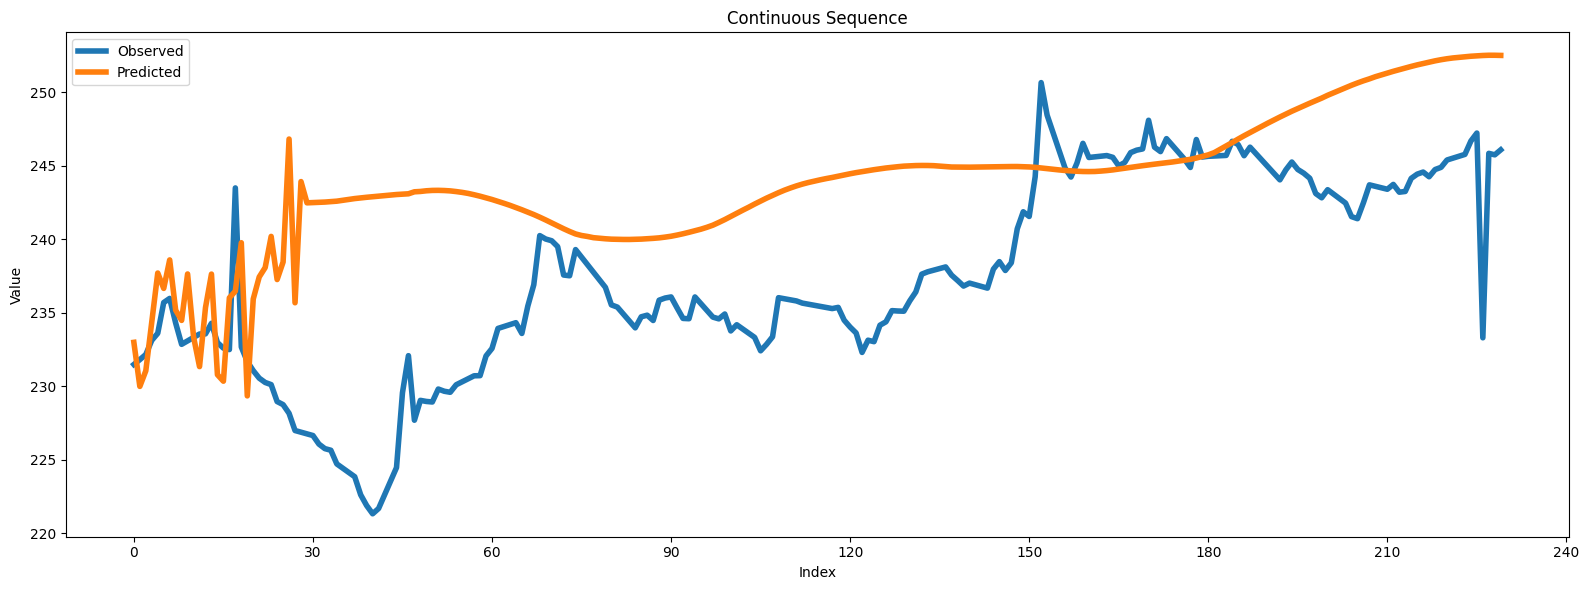

In [ ]:
plot_continuous(observed_full, predicted_full, figsize=(16, 6), linewidth=4)

### Calculate R^2

In [ ]:
import numpy as np


def r2_score(observed, predicted):
    observed = np.array(observed)
    predicted = np.array(predicted)

    ss_res = np.sum((observed - predicted) ** 2)  # Residual sum of squares
    ss_tot = np.sum((observed - np.mean(observed)) ** 2)  # Total sum of squares

    return 1 - (ss_res / ss_tot)

In [ ]:
print(r2_score(observed_full, predicted_full))

-0.6336741061518596


In [ ]:
# tensorboard --logdir=src/model/lightning_logs/